# Cav1.2: predicted and experimental distance analysis

This notebook compares Cα–Cα distance distributions from AlphaFold2 ensembles with
distances measured in experimental structures. Data are loaded from versioned GitHub
raw URLs so the analysis can run outside the original workstation.

## Interpretation guide

- A narrow violin indicates that the predicted ensemble consistently samples a similar geometry.
- An experimental marker inside the main violin density is compatible with the predicted ensemble.
- A marker near a tail indicates partial or rare sampling of the experimental conformation.
- A marker outside the predicted range identifies a systematic structural difference worth inspecting.

Distances alone do **not** constitute a structural superposition. They are invariant to rigid-body
alignment and therefore allow local geometry comparisons without superposing coordinates. A true
superposition analysis (aligned Cα RMSD, aligned residue coverage, and domain-specific RMSD) requires
the predicted and experimental coordinate files, which are not included in this repository. The
distance comparisons below should consequently be interpreted as local structural agreement, not
as a global RMSD analysis.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import sys
repo_root = Path.cwd() if (Path.cwd() / 'shared').is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo_root)) if str(repo_root) not in sys.path else None
from shared.dataset_selection import distance_csv_options, load_selected_distance_csv


In [2]:
# Cav1.2 WT and mutant ensembles: explicit paths and one shared selection.
DATASET_SELECTION = 'all_ok_3'  # Corrected 3 Å convergence subset stored in cav12/dataDistances; switch to 'all' to inspect unfiltered rows.
data = repo_root / 'cav12' / 'dataDistances'
DATASET_PATHS = {
    'WT vanilla': distance_csv_options(repo_root, data / '26-02-10_Cav12_wt_vanillaAF2_distances_all.csv', 'Cav12', 'WT', 'vanilla'),
    'WT masked': distance_csv_options(repo_root, data / '26-02-10_Cav12_wt_maskedAF2_distances_all.csv', 'Cav12', 'WT', 'masked'),
    'G402S vanilla': distance_csv_options(repo_root, data / '26-02-10_Cav12_g402s_vanillaAF2_distances_all.csv', 'Cav12', 'G402S', 'vanilla'),
    'G402S masked': distance_csv_options(repo_root, data / '26-02-10_Cav12_g402s_maskedAF2_distances_all.csv', 'Cav12', 'G402S', 'masked'),
    'G406R vanilla': distance_csv_options(repo_root, data / '26-07-25_Cav1.2_g406r_vanillaAF2_distances_all.csv', 'Cav12', 'G406R', 'vanilla'),
    'G406R masked': distance_csv_options(repo_root, data / '26-07-25_Cav1.2_g406r_maskedAF2_distances_all.csv', 'Cav12', 'G406R', 'masked'),
}
DATASET_PATHS
df_wt_vanilla = load_selected_distance_csv('WT vanilla', DATASET_PATHS['WT vanilla'], DATASET_SELECTION)
df_wt_masked = load_selected_distance_csv('WT masked', DATASET_PATHS['WT masked'], DATASET_SELECTION)
df_g402s_vanilla = load_selected_distance_csv('G402S vanilla', DATASET_PATHS['G402S vanilla'], DATASET_SELECTION)
df_g402s_masked = load_selected_distance_csv('G402S masked', DATASET_PATHS['G402S masked'], DATASET_SELECTION)
df_g406r_vanilla = load_selected_distance_csv('G406R vanilla', DATASET_PATHS['G406R vanilla'], DATASET_SELECTION)
df_g406r_masked = load_selected_distance_csv('G406R masked', DATASET_PATHS['G406R masked'], DATASET_SELECTION)
print(f'Loaded WT, G402S, and G406R datasets using requested selection: {DATASET_SELECTION}')


WT vanilla: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_wt_vanillaAF2_distances_all_ok_rmsd_3A.csv
WT masked: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_wt_maskedAF2_distances_all_ok_rmsd_3A.csv
G402S vanilla: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_g402s_vanillaAF2_distances_all_ok_rmsd_3A.csv
G402S masked: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_g402s_maskedAF2_distances_all_ok_rmsd_3A.csv
G406R vanilla: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-07-25_Cav1.2_g406r_vanillaAF2_distances_all_ok_rmsd_3A.csv
G406R masked: requested=all_ok_3; actual=all_ok_3; path=/Users/ah

## Experimental-distance comparisons

Experimental markers provide local structural references for the selectivity filter, intracellular
gate, and voltage sensors. WT and mutant ensembles are compared with identical residue definitions,
using the 3 Å convergence-filtered datasets throughout.


In [3]:
# Experimental marker palette: distinct, high-contrast accents on white marker faces.
CAV12_PALETTE = {'WT_VAN':'#DCEBF8','WT_HM':'#5E98CB','G402S_VAN':'#B8E2F0','G402S_HM':'#3C8EAA','G406R_VAN':'#C8DAF6','G406R_HM':'#4B77C8'}
CAV_EXPERIMENTAL_COLORS = [
    "#E57373", "#F48FB1", "#F06292", "#FF8A65",
    "#FFB74D", "#FFCC99", "#FFD89A", "#FFE082", "#FFF176", "#FFF6B3",
]


In [4]:
def plot_distances_by_alias_violin(
    df,
    alias_dict,
    exp_distances_list=None,
    title_custom_add='Cav1.2 | WT | masked | Voltage sensor',
    colors=None,
    fig_width=6,
    fig_height=6,
    dataset_labels=None,
    pdb_colors=None
):
    """
    Plots the distribution of distances by alias based on the specified columns.
    """

    aliases_in_order = list(alias_dict.keys())
    plot_records = []

    for alias in aliases_in_order:
        column_name = alias_dict[alias]
        if column_name not in df.columns:
            print(f"Warning: Column '{column_name}' not found in the DataFrame; alias '{alias}' will still appear empty.")
            plot_records.append({"Alias": alias, "Distance": None})
            continue

        distances = df[column_name].dropna()
        for d in distances.tolist():
            plot_records.append({"Alias": alias, "Distance": d})

        if len(distances) == 0:
            plot_records.append({"Alias": alias, "Distance": None})

    if not plot_records:
        print("No distances found to plot after checking provided columns.")
        return

    plot_df = pd.DataFrame(plot_records)
    plot_df["Alias"] = pd.Categorical(plot_df["Alias"], categories=aliases_in_order, ordered=True)

    sns.set(style="whitegrid", rc={"grid.linewidth": 0.5, "grid.color": "#dcdcdc"})

    n_aliases = len(aliases_in_order)
    if colors is not None and len(colors) == n_aliases:
        palette = colors
    else:
        palette = sns.color_palette("coolwarm", n_aliases)

    plt.figure(figsize=(fig_width, fig_height))
    sns.violinplot(
        x='Alias',
        y='Distance',
        data=plot_df,
        order=aliases_in_order,
        palette=palette,
        inner='box',
        cut=0,
        linewidth=0.8
    )

    if exp_distances_list and dataset_labels:
        if pdb_colors and len(pdb_colors) == len(exp_distances_list):
            colors_for_pdb = pdb_colors
        else:
            colors_for_pdb = [CAV_EXPERIMENTAL_COLORS[i % len(CAV_EXPERIMENTAL_COLORS)] for i in range(len(exp_distances_list))]

        marker_styles = ['o', 's', 'D', '^', 'v', 'P', '*', 'X','d','<','>']
        used_label = [False] * len(exp_distances_list)

        for i, exp_distances_dict in enumerate(exp_distances_list):
            for alias, exp_distances in exp_distances_dict.items():
                if alias not in aliases_in_order:
                    continue
                xpos = aliases_in_order.index(alias)
                for exp_distance in exp_distances:
                    plt.scatter(
                        [xpos], [exp_distance],
                        facecolors='white',
                        edgecolors=colors_for_pdb[i],
                        linewidths=0.9,
                        s=42,
                        zorder=5,
                        marker=marker_styles[i % len(marker_styles)],
                        label=(dataset_labels[i] if not used_label[i] else None)
                    )
                    used_label[i] = True

    plt.title(f'Distribution of Distances {title_custom_add}', fontsize=18, weight='light', pad=20)
    plt.xlabel('Pair of αC', fontsize=24, weight='light')
    plt.ylabel('Distance (Å)', fontsize=24, weight='light')
    plt.grid(True, linestyle='--', linewidth=0.5, color='#dcdcdc')
    plt.xticks(rotation=45, ha='right', fontsize=12, weight='light')
    sns.despine()
    plt.tight_layout()

    handles, labels = plt.gca().get_legend_handles_labels()
    if any(lbl for lbl in labels):
        plt.legend(
            bbox_to_anchor=(1.05, 1),
            loc='upper left',
            borderaxespad=0.0
        )

    plt.show()


/var/folders/m9/fym_fwtx3554t2jjfnw3s5cw0000gp/T/ipykernel_27363/979581670.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


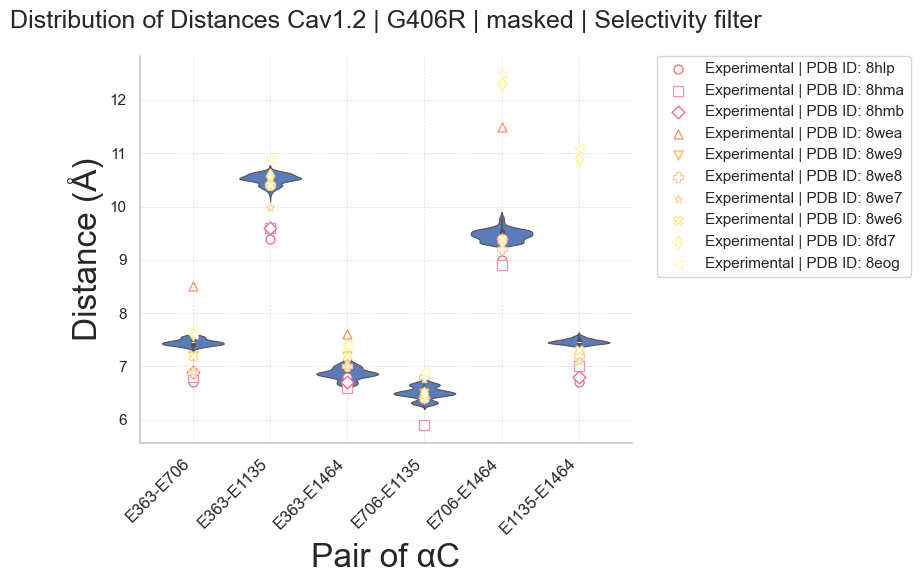

/var/folders/m9/fym_fwtx3554t2jjfnw3s5cw0000gp/T/ipykernel_27363/979581670.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


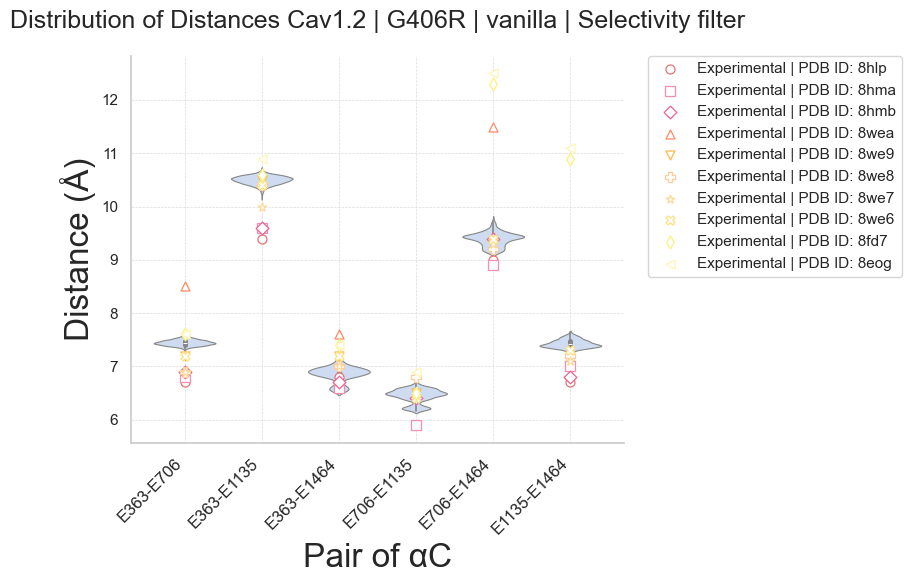

In [5]:
# Selectivity-filter distance set.
alias_dict = {
    'E363-E706': 'CA_GLU363_CA-GLU706_CA',
    'E363-E1135': 'CA_GLU363_CA-GLU1135_CA',
    'E363-E1464': 'CA_GLU363_CA-GLU1464_CA',
    'E706-E1135': 'CA_GLU706_CA-GLU1135_CA',
    'E706-E1464': 'CA_GLU706_CA-GLU1464_CA',
    'E1135-E1464': 'CA_GLU1135_CA-GLU1464_CA',
}

# Colors distinguish the six selectivity-filter pairs.
custom_colors = ['#53acc9', '#89d7eb', '#91c7f9', '#53acc9', '#4dabae', '#9370DB']

# Experimental distances to overlay (multiple datasets with lists for each alias)
exp_distances_list = [
    { #8hlp
        'E363-E706': [6.7],
        'E363-E1135': [9.4],
        'E363-E1464': [6.8],
        'E706-E1135': [5.9],
        'E706-E1464': [9.0],
        'E1135-E1464': [6.7]
    },
    { #8hma
        'E363-E706': [6.8],
        'E363-E1135': [9.6],
        'E363-E1464': [6.6],
        'E706-E1135': [5.9],
        'E706-E1464': [8.9],
        'E1135-E1464': [7.0]
    },
    { #8hmb
        'E363-E706': [6.9],
        'E363-E1135': [9.6],
        'E363-E1464': [6.7],
        'E706-E1135': [6.4],
        'E706-E1464': [9.4],
        'E1135-E1464': [6.8]
    },
    { #8wea
        'E363-E706': [8.5],
        #'E363-E1135': [],
        'E363-E1464': [7.6],
        #'E706-E1135': [],
        'E706-E1464': [11.5],
        #'E1135-E1464': []
    },
    { #8we9
        'E363-E706': [7.2],
        'E363-E1135': [10.5],
        'E363-E1464': [7.2],
        'E706-E1135': [6.5],
        'E706-E1464': [9.3],
        'E1135-E1464': [7.2]
    },
    { #8we8
        'E363-E706': [6.9],
        'E363-E1135': [10.4],
        'E363-E1464': [7.0],
        'E706-E1135': [6.8],
        'E706-E1464': [9.2],
        'E1135-E1464': [7.2]
    },
    { #8we7
        'E363-E706': [6.9],
        'E363-E1135': [10.0],
        'E363-E1464': [7.0],
        'E706-E1135': [6.4],
        'E706-E1464': [9.3],
        'E1135-E1464': [7.1]
    },
    { #8we6
        'E363-E706': [7.2],
        'E363-E1135': [10.4],
        'E363-E1464': [7.2], 
        'E706-E1135': [6.4],
        'E706-E1464': [9.4],
        'E1135-E1464': [7.3]
    },
    { #8fd7
        'E363-E706': [7.6],
        'E363-E1135': [10.6], #E1115
        'E363-E1464': [7.4],#1416
        'E706-E1135': [6.5], #E1115
        'E706-E1464': [12.3],
        'E1135-E1464': [10.9]
    },
    { #8eog
        'E363-E706': [7.6],
        'E363-E1135': [10.9],
        'E363-E1464': [7.4],#1416
        'E706-E1135': [6.9],
        'E706-E1464': [12.5],
        'E1135-E1464': [11.1]
    }
]

# Labels for the datasets
dataset_labels = ['Experimental | PDB ID: 8hlp', 'Experimental | PDB ID: 8hma', 'Experimental | PDB ID: 8hmb','Experimental | PDB ID: 8wea','Experimental | PDB ID: 8we9','Experimental | PDB ID: 8we8','Experimental | PDB ID: 8we7','Experimental | PDB ID: 8we6','Experimental | PDB ID: 8fd7','Experimental | PDB ID: 8eog']

# Custom colors for each PDB dataset
pdb_colors = ['#AC5336', '#D77614','#F99E09','#AC5336','#AB524D','#6BD0A3']

# Compare the masked and vanilla G406R ensembles with the same references.
#plot_distances_by_alias_violin(df, alias_dict, xp_distances_list=exp_distances_list, title_custom_add='Selectivity Filter Subsampling 32-64', colors=[CAV12_PALETTE['G406R_HM']] * len(alias_dict), fig_width=14, fig_height=8, dataset_labels=dataset_labels, pdb_colors=pdb_colors)
plot_distances_by_alias_violin(df_g406r_masked , alias_dict, exp_distances_list=exp_distances_list, title_custom_add='Cav1.2 | G406R | masked | Selectivity filter', colors=[CAV12_PALETTE['G406R_HM']] * len(alias_dict), fig_width=6, fig_height=6, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)
plot_distances_by_alias_violin(df_g406r_vanilla, alias_dict, exp_distances_list=exp_distances_list, title_custom_add='Cav1.2 | G406R | vanilla | Selectivity filter', colors=[CAV12_PALETTE['G406R_VAN']] * len(alias_dict), fig_width=6, fig_height=6, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)


/var/folders/m9/fym_fwtx3554t2jjfnw3s5cw0000gp/T/ipykernel_27363/979581670.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


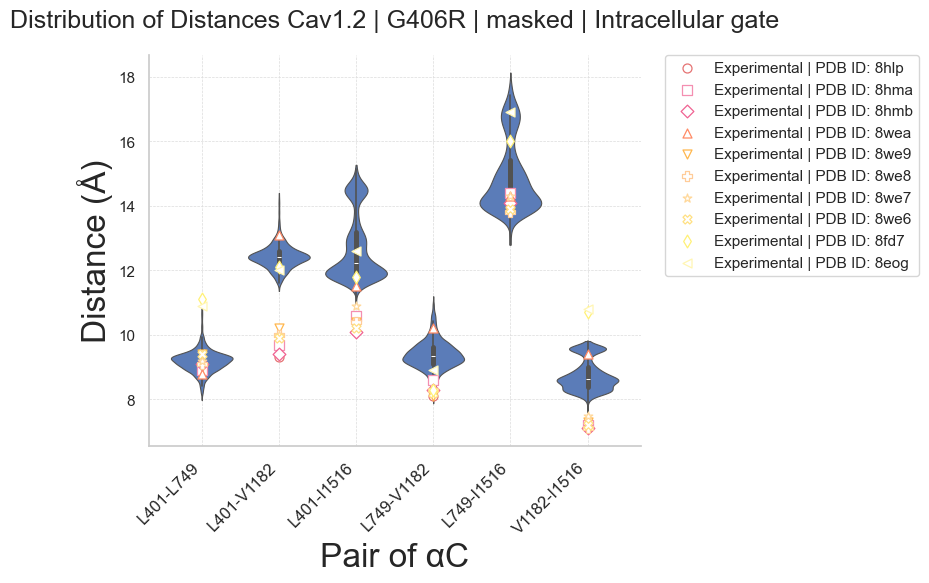

/var/folders/m9/fym_fwtx3554t2jjfnw3s5cw0000gp/T/ipykernel_27363/979581670.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


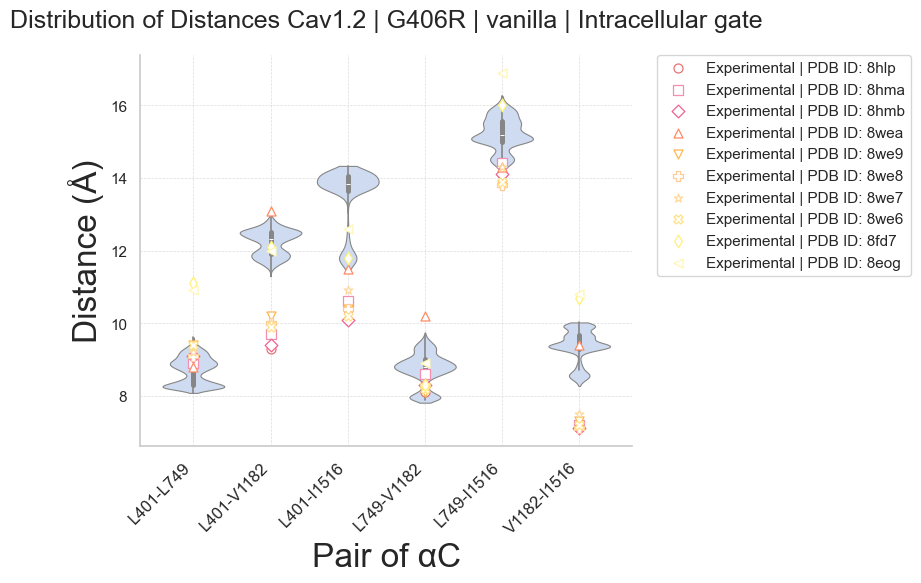

In [6]:
# Intracellular-gate distance set.
alias_dict = {
    'L401-L749':'CA_LEU401_CA-LEU749_CA',
    'L401-V1182':'CA_LEU401_CA-VAL1182_CA',
    'L401-I1516':'CA_LEU401_CA-ILE1516_CA',
    'L749-V1182':'CA_LEU749_CA-VAL1182_CA',
    'L749-I1516':'CA_LEU749_CA-ILE1516_CA',
    'V1182-I1516':'CA_VAL1182_CA-ILE1516_CA'
}

# A related color family keeps the six gate pairs visually grouped.
custom_colors = ['#eb5c9e', '#ea96a3', '#e689e6', '#e891c3', '#d057a8', '#e1818f']

# Experimental distances to overlay (example values, with lists for each alias)
exp_distances_list = [
    { #8hlp
    'L401-L749':[8.9],
    'L401-V1182':[9.3],
    'L401-I1516':[10.4],
    'L749-V1182':[8.1],
    'L749-I1516':[14.1],
    'V1182-I1516':[7.1]
}, { #8hma
    'L401-L749':[8.9],
    'L401-V1182':[9.7],
    'L401-I1516':[10.6],
    'L749-V1182':[8.6],
    'L749-I1516':[14.4],
    'V1182-I1516':[7.2]
}, { #8hmb
    'L401-L749':[9.1],
    'L401-V1182':[9.4],
    'L401-I1516':[10.1],
    'L749-V1182':[8.3],
    'L749-I1516':[14.1],
    'V1182-I1516':[7.1]
}, { #8wea
    'L401-L749':[8.8],
    'L401-V1182':[13.1],
    'L401-I1516':[11.5],
    'L749-V1182':[10.2],
    'L749-I1516':[14.3],
    'V1182-I1516':[9.4]
}, { #8we9
    'L401-L749':[9.4],
    'L401-V1182':[10.2],
    'L401-I1516':[10.4],
    'L749-V1182':[8.1],
    'L749-I1516':[13.8],
    'V1182-I1516':[7.3]
}, { #8we8
    'L401-L749':[9.1],
    'L401-V1182':[10.0],
    'L401-I1516':[10.4],
    'L749-V1182':[8.3],
    'L749-I1516':[13.8],
    'V1182-I1516':[7.1]
}, { #8we7
    'L401-L749':[9.2],
    'L401-V1182':[10.0],
    'L401-I1516':[10.9],
    'L749-V1182':[8.2],
    'L749-I1516':[14.3],
    'V1182-I1516':[7.5]
}, { #8we6
    'L401-L749':[9.4],
    'L401-V1182':[9.9],
    'L401-I1516':[10.2],
    'L749-V1182':[8.2],
    'L749-I1516':[13.9],
    'V1182-I1516':[7.2]
}, { #8fd7
    'L401-L749':[11.1],
    'L401-V1182':[12.1], #1162
    'L401-I1516':[11.8], #1468
    'L749-V1182':[8.3], #1162
    'L749-I1516':[16],
    'V1182-I1516':[10.7]
}, { #
    'L401-L749':[10.9],
    'L401-V1182':[12.0],
    'L401-I1516':[12.6],
    'L749-V1182':[8.9],
    'L749-I1516':[16.9],
    'V1182-I1516':[10.8]
}
]
# Labels for the datasets
dataset_labels = ['Experimental | PDB ID: 8hlp', 'Experimental | PDB ID: 8hma', 'Experimental | PDB ID: 8hmb','Experimental | PDB ID: 8wea','Experimental | PDB ID: 8we9','Experimental | PDB ID: 8we8','Experimental | PDB ID: 8we7','Experimental | PDB ID: 8we6','Experimental | PDB ID: 8fd7','Experimental | PDB ID: 8eog']

# Custom colors for each PDB dataset
pdb_colors = ['#ff5733', '#33ff57', '#3375ff', '#ff33c4', '#ffd633', '#33fff5']

# Compare the masked and vanilla G406R gate distributions.
plot_distances_by_alias_violin(df_g406r_masked, alias_dict, exp_distances_list=exp_distances_list, title_custom_add='Cav1.2 | G406R | masked | Intracellular gate', colors=[CAV12_PALETTE['G406R_HM']] * len(alias_dict), fig_width=6, fig_height=6, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)

plot_distances_by_alias_violin(df_g406r_vanilla, alias_dict, exp_distances_list=exp_distances_list, title_custom_add='Cav1.2 | G406R | vanilla | Intracellular gate', colors=[CAV12_PALETTE['G406R_VAN']] * len(alias_dict), fig_width=6, fig_height=6, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)


/var/folders/m9/fym_fwtx3554t2jjfnw3s5cw0000gp/T/ipykernel_27363/979581670.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


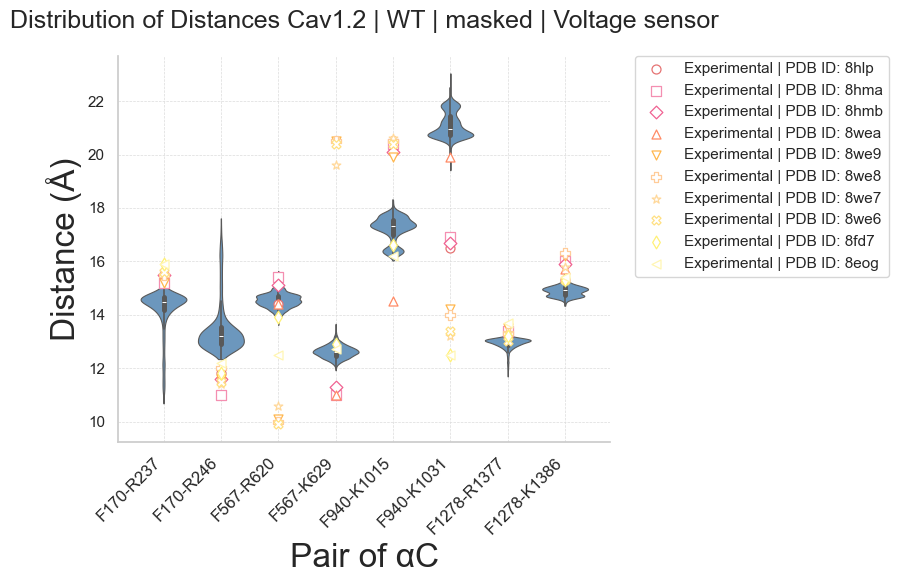

/var/folders/m9/fym_fwtx3554t2jjfnw3s5cw0000gp/T/ipykernel_27363/979581670.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


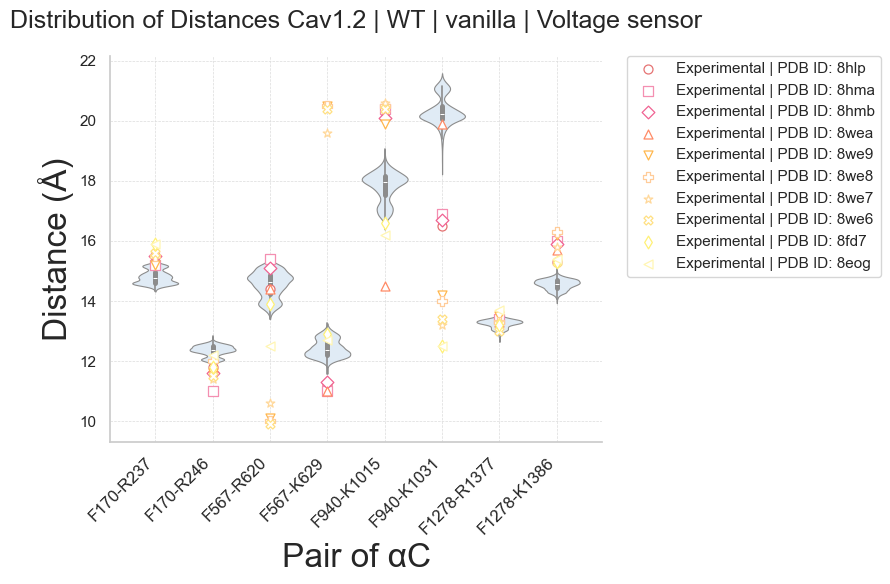

In [7]:
# Gating charges vs the aromatic middle in S2
alias_dict = {
    'F170-R237': 'CA_ARG237_CA-PHE170_CA',
    'F170-R246': 'CA_ARG246_CA-PHE170_CA',
    'F567-R620': 'CA_ARG620_CA-PHE567_CA',
    'F567-K629': 'CA_LYS629_CA-PHE567_CA',####
    'F940-K1015': 'CA_LYS1015_CA-PHE940_CA',
    'F940-K1031': 'CA_ARG1031_CA-PHE940_CA',
    'F1278-R1377': 'CA_ARG1377_CA-PHE1278_CA',
    'F1278-K1386': 'CA_LYS1386_CA-PHE1278_CA',
    #'F1278-R1390': 'CA_ARG1279_CA-PHE1167_CA',
}

# Colors distinguish the voltage-sensor measurements.
custom_colors = ['#9fa046','#92a348', '#7aaa48','#6aae52', '#4fb38c','#4aac99','#43b5b1','#3ebbbd']

# Experimental distances to overlay (multiple datasets with lists for each alias)
exp_distances_list = [
    { #8hlp
    'F170-R237': [15.3],
    'F170-R246': [11.8],
    'F567-R620': [14.4],
    'F567-K629': [11.2],
    'F940-K1015': [20.3],
    'F940-K1031': [16.5],
    'F1278-R1377': [13.4],
    'F1278-K1386':[15.3],
    #'F1278-R1390': [20.2]
   },
    { #8hma
     'F170-R237': [15.2],
    'F170-R246': [11.0],
    'F567-R620': [15.4],
    'F567-K629': [11.0],
    'F940-K1015': [20.4],
    'F940-K1031': [16.9],
    'F1278-R1377': [13.4],
    'F1278-K1386':[16.0],
    #'F1278-R1390': [20.8]
    },
    { #8hmb
    'F170-R237': [15.5],
    'F170-R246': [11.6],
    'F567-R620': [15.1],
    'F567-K629': [11.3],
    'F940-K1015': [20.1],
    'F940-K1031': [16.7],
    'F1278-K1386':[15.9],
   # 'F1278-R1390': [20.5]    
    },
    { #8wea
    'F170-R237': [15.6],
    'F170-R246': [11.8],
    'F567-R620': [14.4],
    'F567-K629': [11.0],
    'F940-K1015': [14.5], #960
    'F940-K1031': [19.9], #960,1027
    'F1278-R1377': [13.3],
    'F1278-K1386':[15.7],
    #'F1278-R1390': [21.2]   
    },
    { #8we9
    'F170-R237': [15.2],
    'F170-R246': [11.6],
    'F567-R620': [10.1],
    'F567-K629': [20.5],
    'F940-K1015': [19.9],
    'F940-K1031': [14.2],
    'F1278-R1377': [13.5],
    'F1278-K1386':[16.2],
    #'F1278-R1390': [20.9]    
    },
    { #8we8
    'F170-R237': [15.5],
    'F170-R246': [12.0],
    'F567-R620': [10.0],
    'F567-K629': [20.5],
    'F940-K1015': [20.5],
    'F940-K1031': [14.0],
    'F1278-R1377': [13.3],
    'F1278-K1386':[16.3],
    #'F1278-R1390': [21.5]    
    },
    { #8we7
    'F170-R237': [15.6],
    'F170-R246': [11.4],
    'F567-R620': [10.6],
    'F567-K629': [19.6],
    'F940-K1015': [20.6],
    'F940-K1031': [13.2],
    'F1278-R1377': [13.3],
    'F1278-K1386': [15.8], #1278,1386
    #'F1278-R1390': [20.2]    
    },
    { #8we6
    'F170-R237': [15.6],
    'F170-R246': [11.5],
    'F567-R620': [9.9],
    'F567-K629': [20.4],
    'F940-K1015': [20.4],
    'F940-K1031': [13.4],
    'F1278-R1377': [13.0],
    'F1278-K1386': [15.3], #1258
    #'F1278-R1390': [21.4]    
    },
    { #8fd7
    'F170-R237': [15.9],
    'F170-R246': [11.8],
    'F567-R620': [13.9],
    'F567-K629': [12.9], 
    'F940-K1015': [16.6], #F944,995
    'F940-K1031': [12.5],
    'F1278-R1377': [13.2], #1258,1329
    'F1278-K1386': [15.3],
    #'F1278-R1390': [20.2] #1258,1342
    },
    { #8eog
    'F170-R237': [15.9],
    'F170-R246': [12.2],
    'F567-R620': [12.5],
    'F567-K629': [12.7],
    'F940-K1015': [16.2],
    'F940-K1031': [12.5],
    'F1278-R1377': [13.7],
    'F1278-K1386': [15.4],
    #'F1278-R1390': [20.5]    
    }
]

# Labels for the datasets
dataset_labels = ['Experimental | PDB ID: 8hlp', 'Experimental | PDB ID: 8hma', 'Experimental | PDB ID: 8hmb','Experimental | PDB ID: 8wea','Experimental | PDB ID: 8we9','Experimental | PDB ID: 8we8','Experimental | PDB ID: 8we7','Experimental | PDB ID: 8we6','Experimental | PDB ID: 8fd7','Experimental | PDB ID: 8eog']

# Custom colors for each PDB dataset
pdb_colors = ['#AC5336', '#D77614','#F99E09','#AC5336','#AB524D','#6BD0A3','#50C878','#88D499']

# WT voltage-sensor distributions with experimental references.
plot_distances_by_alias_violin(df_wt_masked , alias_dict, exp_distances_list=exp_distances_list, title_custom_add='Cav1.2 | WT | masked | Voltage sensor', colors=[CAV12_PALETTE['WT_HM']] * len(alias_dict), fig_width=6, fig_height=6, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)

plot_distances_by_alias_violin(df_wt_vanilla, alias_dict, exp_distances_list=exp_distances_list, title_custom_add='Cav1.2 | WT | vanilla | Voltage sensor', colors=[CAV12_PALETTE['WT_VAN']] * len(alias_dict), fig_width=6, fig_height=6, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)


In [8]:
def plot_split_violin(df, alias_dict, title_custom_add='Cav1.2 | WT | masked | Voltage sensor', fig_width=6, fig_height=6, colors=None):
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    aliases = list(alias_dict.keys())
    rec = []

    for alias, columns in alias_dict.items():
        # Distance alias dictionaries use one precomputed column; older
        # split comparisons may still provide a (column_A, column_B) tuple.
        if isinstance(columns, (tuple, list)) and len(columns) == 2:
            colA, colB = columns
        else:
            colA, colB = columns, None
        if colA in df:
            for v in pd.to_numeric(df[colA], errors="coerce").dropna():
                rec.append({"Alias": alias, "Distance": v, "Dataset": "A"})
        else:
            print(f"Warning: missing column {colA}")

        if colB is not None:
            if colB in df:
                for v in pd.to_numeric(df[colB], errors="coerce").dropna():
                    rec.append({"Alias": alias, "Distance": v, "Dataset": "B"})
            else:
                print(f"Warning: missing column {colB}")

    plot_df = pd.DataFrame(rec)
    if plot_df.empty:
        print("No numeric distances found (all NaN after coercion or missing columns).")
        return

    sns.set(style="whitegrid", rc={"grid.linewidth": 0.5, "grid.color": "#dcdcdc"})
    plt.figure(figsize=(fig_width, fig_height))

    palette = colors if colors is not None else sns.color_palette("coolwarm", 2)
    split_mode = plot_df["Dataset"].nunique() == 2

    sns.violinplot(
        data=plot_df,
        x="Alias",
        y="Distance",
        hue="Dataset" if split_mode else None,
        order=aliases,
        hue_order=["A", "B"] if split_mode else None,
        split=split_mode,
        inner="box",
        cut=0,
        linewidth=0.8,
        palette=palette
    )

    plt.title(f"Distribution of Distances {title_custom_add}", fontsize=18, weight="light", pad=20)
    plt.xlabel("Pair of αC", fontsize=24, weight="light")
    plt.ylabel("Distance (Å)", fontsize=24, weight="light")
    plt.grid(True, linestyle="--", linewidth=0.5, color="#dcdcdc")
    plt.xticks(rotation=45, ha="right", fontsize=12, weight="light")
    sns.despine()
    plt.tight_layout()

    # optional: remove legend if you don't want it
    # plt.legend_.remove()

    plt.show()


In [9]:
# Compare the two candidate interaction distances in the WT masked ensemble.
# The experimental-overlay panels below provide the corresponding ensemble comparison.


### Voltage-sensor comparison

Voltage-sensor distances are compared first in WT and then across the two mutant ensembles. The same
residue definitions are retained across protocols so changes in distribution width can be attributed
to masking or mutation rather than to a change in the measurement itself.


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_distances_by_alias_violin_overlay(
    df1,
    df2,
    alias_dict,
    df1_label="Dataset 1",
    df2_label="Dataset 2",
    exp_distances_list=None,     # optional: list of dicts like [{alias:[...], ...}, {...}]
    dataset_labels=None,         # optional: labels for exp_distances_list
    pdb_colors=None,             # optional: colors for exp points
    title_custom_add='Cav1.2 | WT | masked | Voltage sensor',
    colors=None,                 # optional: [color_df1, color_df2]
    alpha=0.45,                  # transparency for violins
    fig_width=6,
    fig_height=6,
    linewidth=0.8,
):
    """
    Overlay violin plots from two dataframes at the same x positions with transparency.

    alias_dict maps display alias -> column name in each dataframe.
    Both df1 and df2 are expected to have those columns (some can be missing).
    """

    aliases_in_order = list(alias_dict.keys())

    def _to_long(df, dataset_name):
        records = []
        for alias in aliases_in_order:
            col = alias_dict[alias]
            if col not in df.columns:
                print(f"Warning: Column '{col}' not found in {dataset_name}; alias '{alias}' will appear empty.")
                records.append({"Alias": alias, "Distance": None, "Dataset": dataset_name})
                continue

            distances = df[col].dropna()
            if len(distances) == 0:
                records.append({"Alias": alias, "Distance": None, "Dataset": dataset_name})
            else:
                records.extend(
                    {"Alias": alias, "Distance": d, "Dataset": dataset_name}
                    for d in distances.tolist()
                )
        return records

    long_records = []
    long_records.extend(_to_long(df1, df1_label))
    long_records.extend(_to_long(df2, df2_label))

    if not long_records:
        print("No distances found to plot after checking provided columns.")
        return

    plot_df = pd.DataFrame(long_records)
    plot_df["Alias"] = pd.Categorical(plot_df["Alias"], categories=aliases_in_order, ordered=True)

    sns.set(style="whitegrid", rc={"grid.linewidth": 0.5, "grid.color": "#dcdcdc"})

    # Colors for the two overlaid datasets
    if colors is not None and len(colors) == 2:
        palette = {df1_label: colors[0], df2_label: colors[1]}
    else:
        # default two distinct colors
        pal2 = sns.color_palette("Set2", 2)
        palette = {df1_label: pal2[0], df2_label: pal2[1]}

    plt.figure(figsize=(fig_width, fig_height))

    ax = sns.violinplot(
        x="Alias",
        y="Distance",
        hue="Dataset",
        data=plot_df,
        order=aliases_in_order,
        palette=palette,
        dodge=False,        # crucial: overlap instead of side-by-side
        cut=0,
        inner="box",
        linewidth=linewidth,
    )

    # Set alpha on the filled violin bodies (PolyCollection objects)
    # (Leave box/lines opaque for readability)
    for coll in ax.collections:
        # Many collections are created; only PolyCollections are the violin bodies.
        # This heuristic works well in practice:
        try:
            coll.set_alpha(alpha)
        except Exception:
            pass

    # Optional: overlay experimental distances (kept similar to your original)
    if exp_distances_list and dataset_labels:
        if pdb_colors and len(pdb_colors) == len(exp_distances_list):
            colors_for_pdb = pdb_colors
        else:
            colors_for_pdb = [CAV_EXPERIMENTAL_COLORS[i % len(CAV_EXPERIMENTAL_COLORS)] for i in range(len(exp_distances_list))]

        marker_styles = ['o', 's', 'D', '^', 'v', 'P', '*', 'X', 'd', '<', '>']
        used_label = [False] * len(exp_distances_list)

        for i, exp_distances_dict in enumerate(exp_distances_list):
            for alias, exp_distances in exp_distances_dict.items():
                if alias not in aliases_in_order:
                    continue
                xpos = aliases_in_order.index(alias)
                for exp_distance in exp_distances:
                    ax.scatter(
                        [xpos], [exp_distance],
                        facecolors="white",
                        edgecolors=colors_for_pdb[i],
                        linewidths=0.9,
                        s=42,
                        zorder=6,
                        marker=marker_styles[i % len(marker_styles)],
                        label=(dataset_labels[i] if not used_label[i] else None)
                    )
                    used_label[i] = True

    ax.set_title(title_custom_add, fontsize=16, weight="semibold", pad=14)
    ax.set_xlabel("Pair of αC", fontsize=24, weight="light")
    ax.set_ylabel("Distance (Å)", fontsize=24, weight="light")
    ax.grid(True, linestyle="--", linewidth=0.5, color="#dcdcdc")
    plt.xticks(rotation=45, ha="right", fontsize=12, weight="light")
    sns.despine()
    plt.tight_layout()

    # Legend: keep one for datasets + optional exp points
    handles, labels = ax.get_legend_handles_labels()
    if any(lbl for lbl in labels):
        ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)

    plt.show()


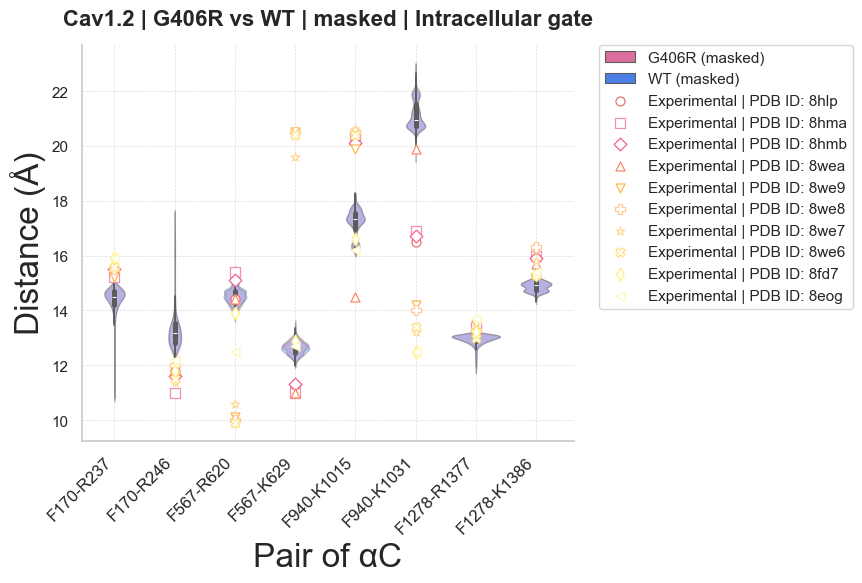

In [11]:
plot_distances_by_alias_violin_overlay(
    df1=df_g406r_masked,
    df2=df_wt_masked,
    alias_dict=alias_dict,
    df1_label="G406R (masked)",
    df2_label="WT (masked)",
    colors=["#eb5c9e", "#3375ff"],   # <- ONLY 2 colors, one per DF
    alpha=0.35,
    title_custom_add="Cav1.2 | G406R vs WT | masked | Intracellular gate",
    fig_width=6,
    fig_height=6,
    exp_distances_list=exp_distances_list,
    dataset_labels=dataset_labels,
    pdb_colors=None,  # or give a list same length as exp_distances_list
)


## Summary

Masking modestly broadens the Cav1.2 ensembles, but the effect is region selective. Voltage-sensor
distances broaden consistently, and the mutant intracellular gates show a larger response than WT,
whereas selectivity-filter geometry remains comparatively constrained. This pattern is consistent
with increased flexibility in mobile gating elements rather than nonspecific pore disruption. The
forthcoming RMSD analysis will determine whether the broader distributions form reproducible states.


## WT–mutant and masked–vanilla comparisons


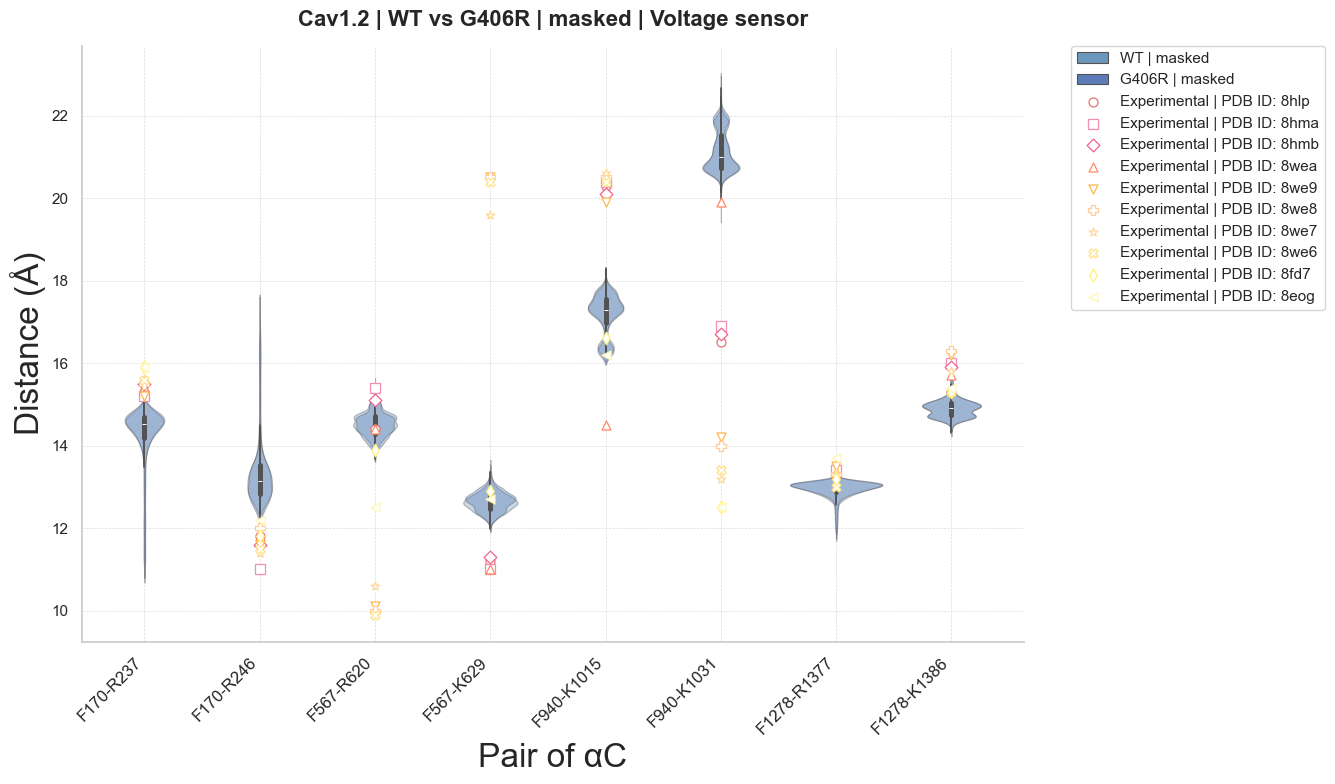

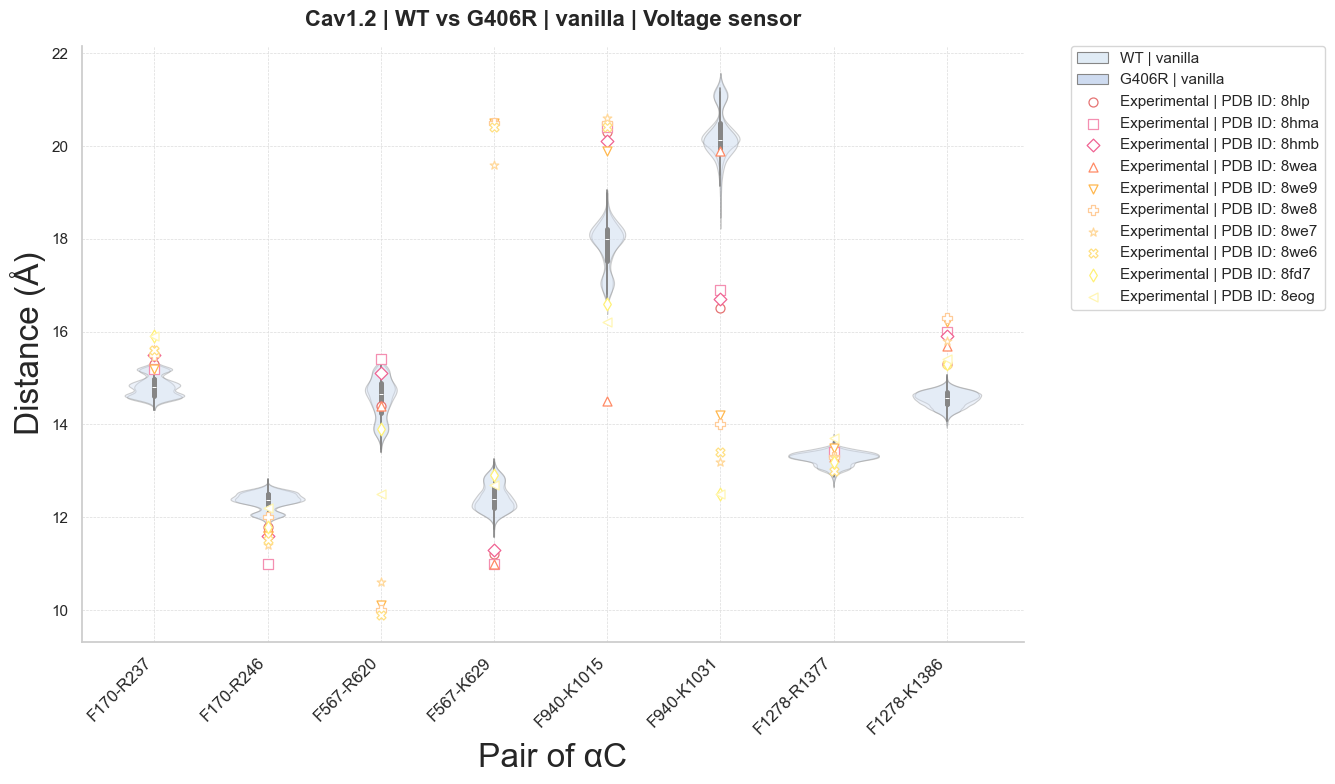

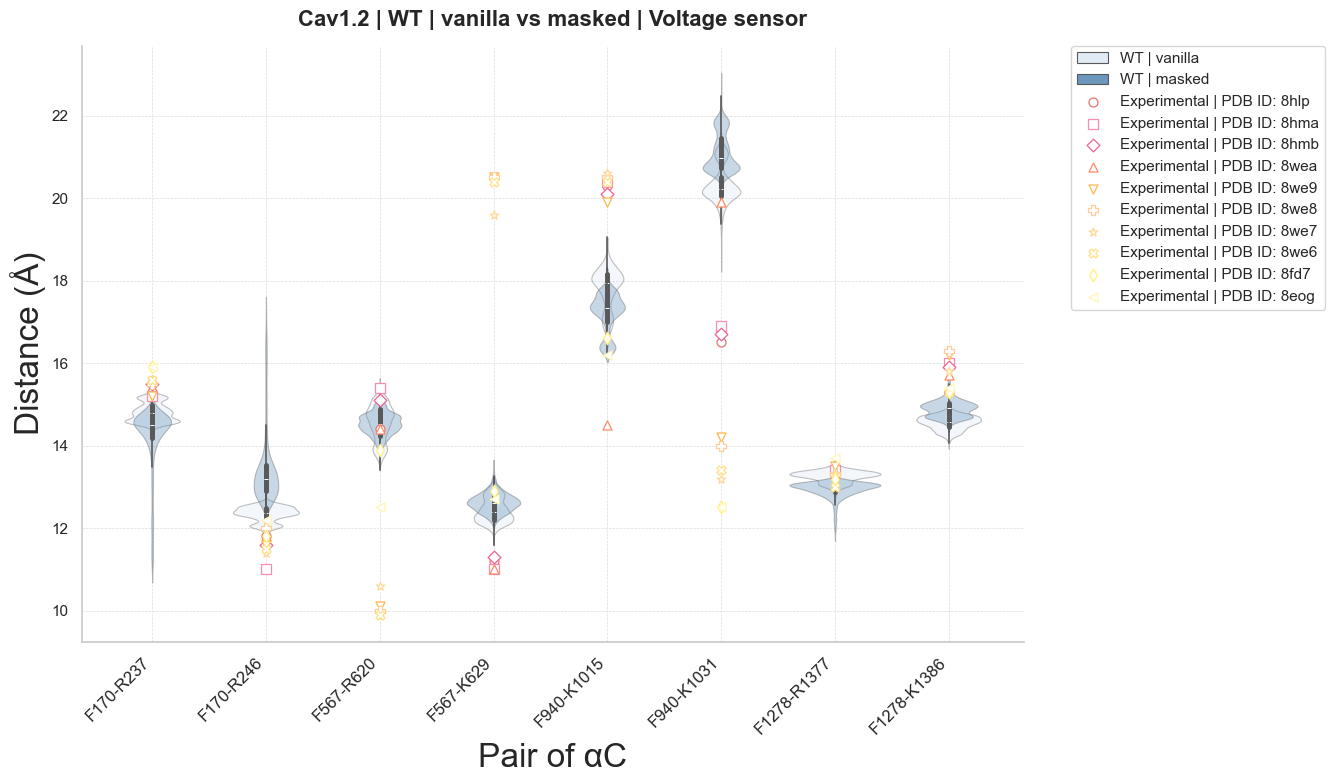

In [12]:
# Comparison panels: WT vs mutant and masked vs vanilla
# The current alias_dict contains the residue-distance set for this region.
plot_distances_by_alias_violin_overlay(
    df1=df_wt_masked, df2=df_g406r_masked, alias_dict=alias_dict,
    df1_label="WT | masked", df2_label="G406R | masked",
    colors=[CAV12_PALETTE["WT_HM"], CAV12_PALETTE["G406R_HM"]], alpha=0.38,
    title_custom_add="Cav1.2 | WT vs G406R | masked | Voltage sensor",
    fig_width=10.5, fig_height=8.0, exp_distances_list=exp_distances_list, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)

plot_distances_by_alias_violin_overlay(
    df1=df_wt_vanilla, df2=df_g406r_vanilla, alias_dict=alias_dict,
    df1_label="WT | vanilla", df2_label="G406R | vanilla",
    colors=[CAV12_PALETTE["WT_VAN"], CAV12_PALETTE["G406R_VAN"]], alpha=0.38,
    title_custom_add="Cav1.2 | WT vs G406R | vanilla | Voltage sensor",
    fig_width=10.5, fig_height=8.0, exp_distances_list=exp_distances_list, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)

plot_distances_by_alias_violin_overlay(
    df1=df_wt_vanilla, df2=df_wt_masked, alias_dict=alias_dict,
    df1_label="WT | vanilla", df2_label="WT | masked",
    colors=[CAV12_PALETTE["WT_VAN"], CAV12_PALETTE["WT_HM"]], alpha=0.38,
    title_custom_add="Cav1.2 | WT | vanilla vs masked | Voltage sensor",
    fig_width=10.5, fig_height=8.0, exp_distances_list=exp_distances_list, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)


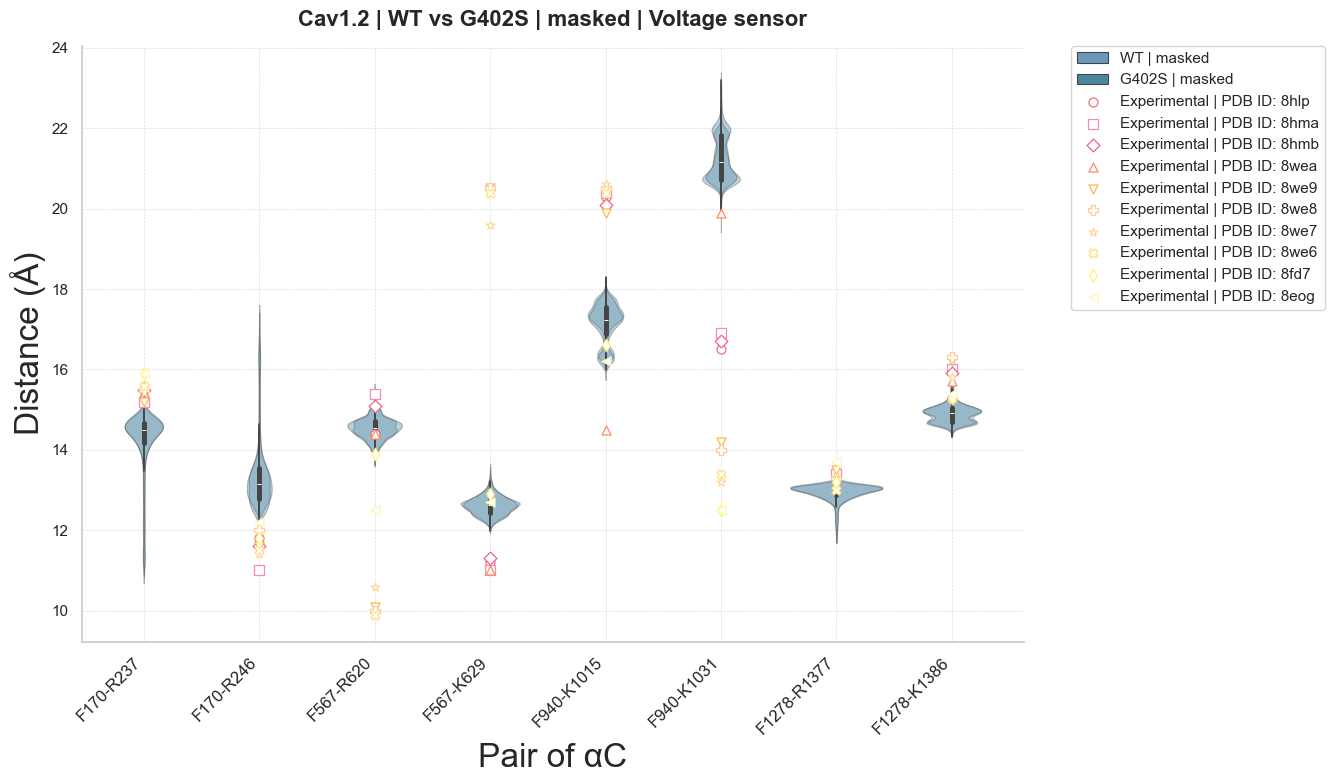

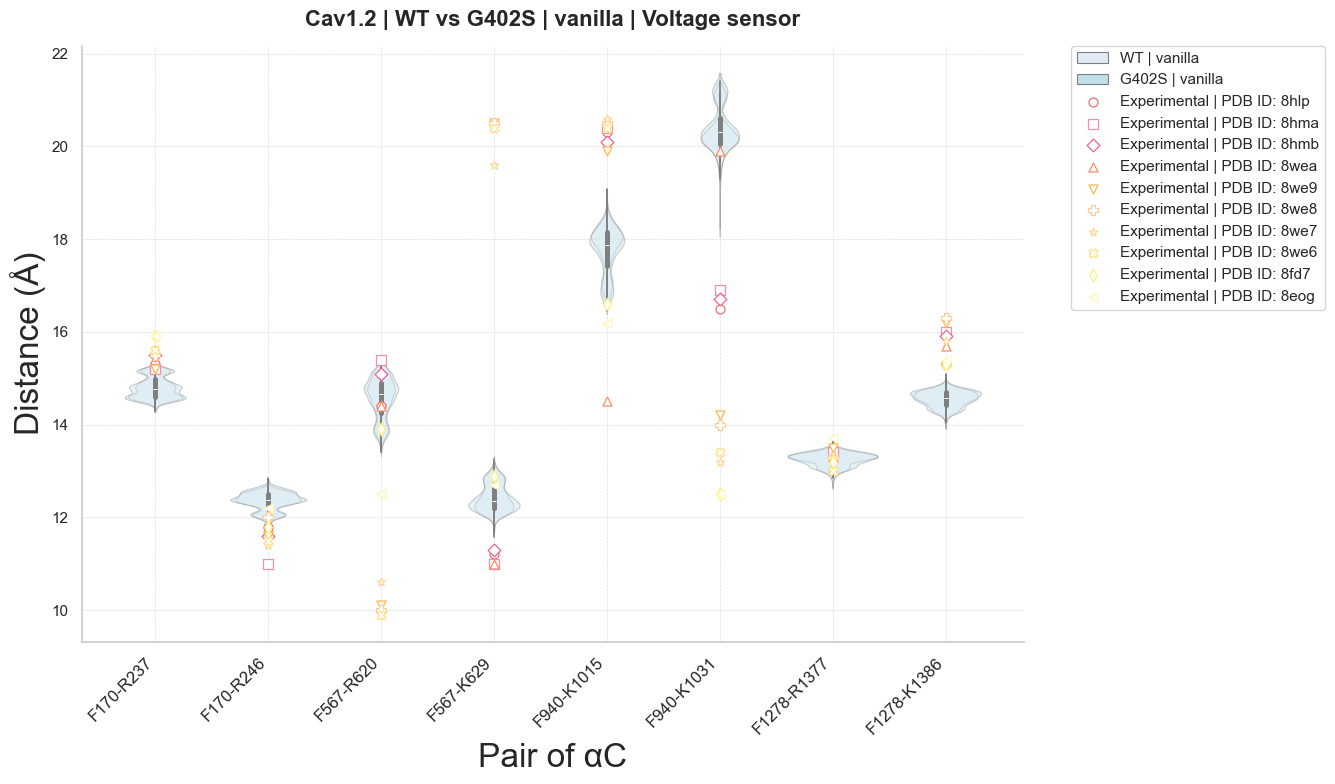

In [13]:
plot_distances_by_alias_violin_overlay(
    df1=df_wt_masked, df2=df_g402s_masked, alias_dict=alias_dict,
    df1_label="WT | masked", df2_label="G402S | masked",
    colors=[CAV12_PALETTE["WT_HM"], CAV12_PALETTE["G402S_HM"]], alpha=0.38,
    title_custom_add="Cav1.2 | WT vs G402S | masked | Voltage sensor",
    fig_width=10.5, fig_height=8.0, exp_distances_list=exp_distances_list, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)

plot_distances_by_alias_violin_overlay(
    df1=df_wt_vanilla, df2=df_g402s_vanilla, alias_dict=alias_dict,
    df1_label="WT | vanilla", df2_label="G402S | vanilla",
    colors=[CAV12_PALETTE["WT_VAN"], CAV12_PALETTE["G402S_VAN"]], alpha=0.38,
    title_custom_add="Cav1.2 | WT vs G402S | vanilla | Voltage sensor",
    fig_width=10.5, fig_height=8.0, exp_distances_list=exp_distances_list, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)


## Mutation-site correspondence comparisons


Cav1.2 selectivity_filter correspondence aliases: ['E363-E706', 'E363-E1135', 'E363-E1464', 'E706-E1135', 'E706-E1464', 'E1135-E1464']


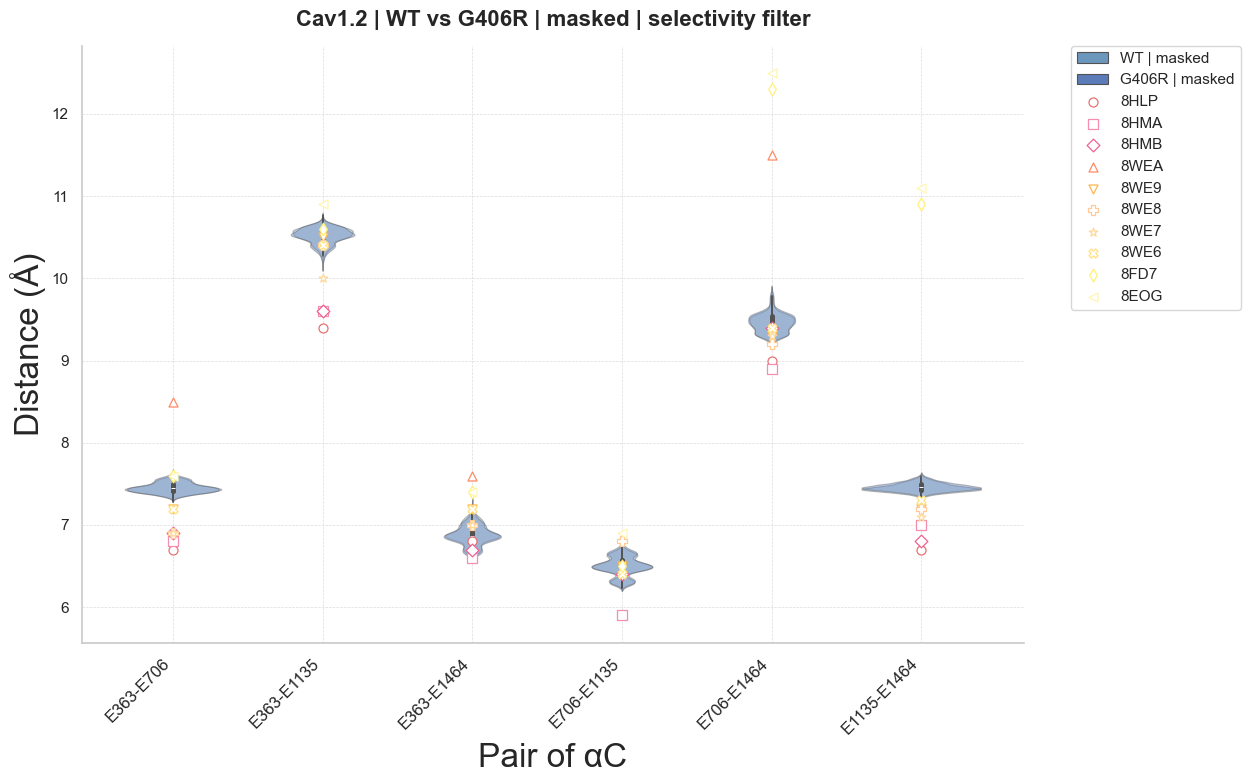

Cav1.2 intracellular_gate correspondence aliases: ['L401-L749', 'L401-V1182', 'L401-I1516', 'L749-V1182', 'L749-I1516', 'V1182-I1516']


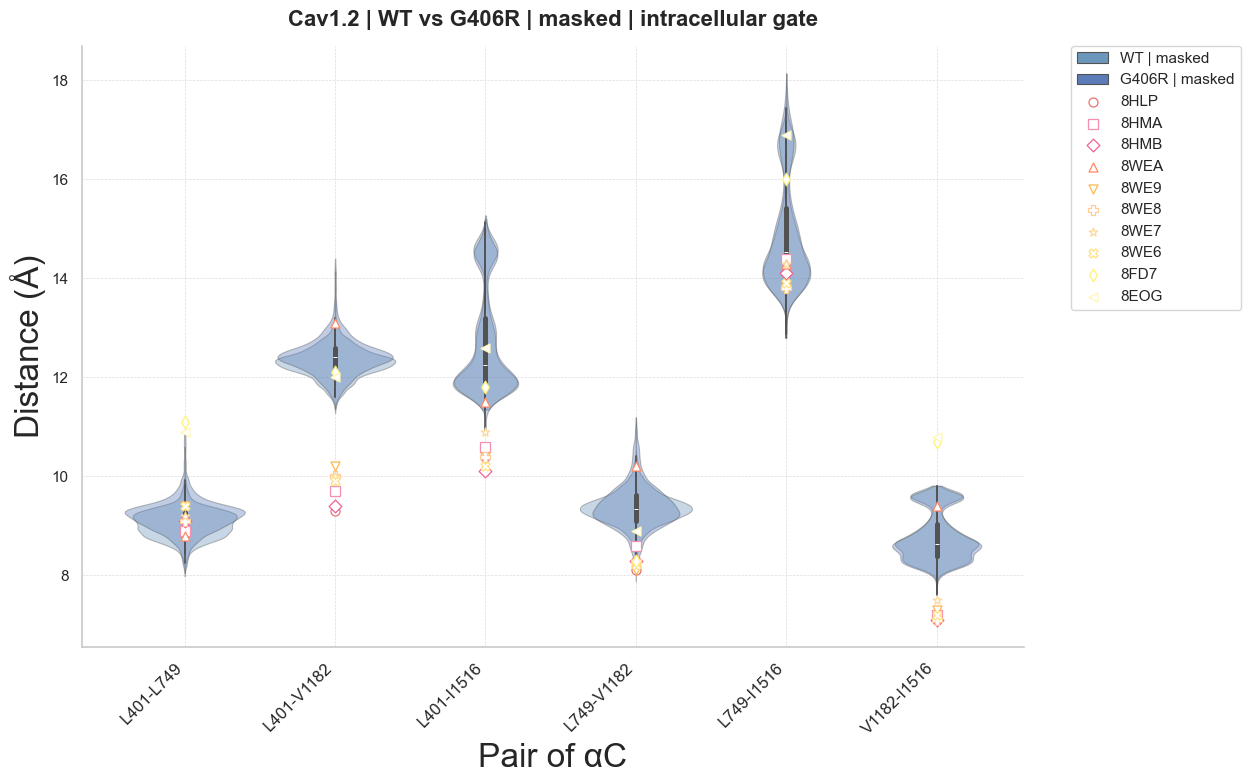

Cav1.2 voltage_sensor correspondence aliases: ['F170-R237', 'F170-R246', 'F567-R620', 'F567-K629', 'F940-K1015', 'F940-K1031', 'F1278-R1377', 'F1278-K1386']


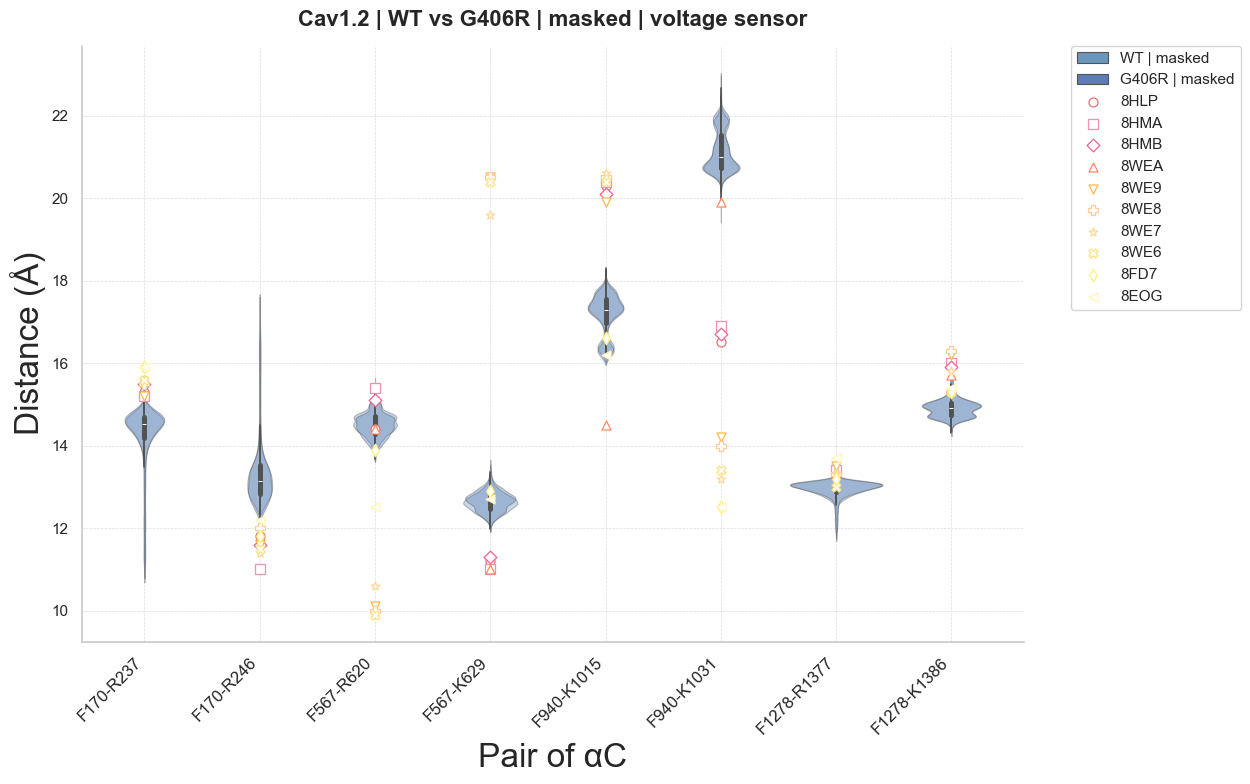

In [14]:
## Cav1.2 mutation-site correspondence distances
CAV12_MUTATION_CORRESPONDENCE = {
    "selectivity_filter": {
        "E363-E706":"CA_GLU363_CA-GLU706_CA", "E363-E1135":"CA_GLU363_CA-GLU1135_CA",
        "E363-E1464":"CA_GLU363_CA-GLU1464_CA", "E706-E1135":"CA_GLU706_CA-GLU1135_CA",
        "E706-E1464":"CA_GLU706_CA-GLU1464_CA", "E1135-E1464":"CA_GLU1135_CA-GLU1464_CA",
    },
    "intracellular_gate": {
        "L401-L749":"CA_LEU401_CA-LEU749_CA", "L401-V1182":"CA_LEU401_CA-VAL1182_CA",
        "L401-I1516":"CA_LEU401_CA-ILE1516_CA", "L749-V1182":"CA_LEU749_CA-VAL1182_CA",
        "L749-I1516":"CA_LEU749_CA-ILE1516_CA", "V1182-I1516":"CA_VAL1182_CA-ILE1516_CA",
    },
    "voltage_sensor": {
        "F170-R237":"CA_ARG237_CA-PHE170_CA", "F170-R246":"CA_ARG246_CA-PHE170_CA",
        "F567-R620":"CA_ARG620_CA-PHE567_CA", "F567-K629":"CA_LYS629_CA-PHE567_CA",
        "F940-K1015":"CA_LYS1015_CA-PHE940_CA", "F940-K1031":"CA_ARG1031_CA-PHE940_CA",
        "F1278-R1377":"CA_ARG1377_CA-PHE1278_CA", "F1278-K1386":"CA_LYS1386_CA-PHE1278_CA",
    },
}
from shared.experimental_overlays import experimental_rows
for _region, _aliases in CAV12_MUTATION_CORRESPONDENCE.items():
    _available = {a:c for a,c in _aliases.items() if c in df_wt_masked.columns and c in df_g406r_masked.columns}
    print(f"Cav1.2 {_region} correspondence aliases:", list(_available))
    if _available:
        _rows = experimental_rows(repo_root, 'Cav1.2', _region, _available)
        _structures = list(dict.fromkeys(row['Structure'] for row in _rows))
        _exp = [{alias: [row['Distance'] for row in _rows if row['Structure'] == structure and row['Alias'] == alias] for alias in _available} for structure in _structures]
        _colors = [next(row['Color'] for row in _rows if row['Structure'] == structure) for structure in _structures]
        plot_distances_by_alias_violin_overlay(
            df1=df_wt_masked, df2=df_g406r_masked, alias_dict=_available,
            df1_label="WT | masked", df2_label="G406R | masked",
            colors=[CAV12_PALETTE["WT_HM"], CAV12_PALETTE["G406R_HM"]], alpha=0.38,
            title_custom_add=f"Cav1.2 | WT vs G406R | masked | {_region.replace('_',' ')}",
            fig_width=10.5, fig_height=8.0, exp_distances_list=_exp, dataset_labels=_structures, pdb_colors=_colors)


## Split-violin comparison alternatives


,Ensemble,Protocol,n,Gate median (Å),Gate IQR (Å),Gate SD (Å),State median (Å),State IQR (Å),Spearman gate–state,Gate IQR / WT,Gate–state coordination,Sampling interpretation
0,WT,vanilla,5000,15.26,0.580,0.485,17.36,0.87,-0.497,1.000,moderate negative,WT reference
1,G402S,vanilla,5000,15.32,0.580,0.458,17.60,0.87,-0.365,1.000,moderate negative,similar gate sampling; coordinated
2,WT,masked,4996,14.46,1.240,1.043,18.04,0.71,-0.526,1.000,strong negative,WT reference
3,G402S,masked,4995,14.58,1.345,1.174,18.39,0.79,-0.517,1.085,strong negative,similar gate sampling; coordinated
4,WT,vanilla,5000,15.26,0.580,0.485,8.92,1.03,0.022,1.000,weak positive,WT reference
5,G406R,vanilla,5000,15.19,0.580,0.450,10.28,0.42,0.278,1.000,weak positive,similar gate sampling; not clearly coordinated
6,WT,masked,4996,14.46,1.240,1.043,9.73,0.61,-0.522,1.000,strong negative,WT reference
7,G406R,masked,4997,14.54,1.350,1.087,10.68,0.41,-0.437,1.089,moderate negative,similar gate sampling; coordinated


,Protocol,VSD landmark,WT median (Å),Mutant median (Å),Mutant − WT (Å),WT IQR (Å),Mutant IQR (Å),Mutant / WT IQR
0,vanilla,F170-R237,14.78,14.77,-0.01,0.370,0.34,0.919
1,vanilla,F170-R246,12.37,12.38,0.01,0.260,0.26,1.000
2,vanilla,F567-R620,14.63,14.66,0.03,0.640,0.60,0.937
3,vanilla,F567-K629,12.38,12.36,-0.02,0.480,0.43,0.896
4,vanilla,F940-K1015,17.95,17.87,-0.08,0.640,0.68,1.062
5,vanilla,F940-K1031,20.22,20.30,0.08,0.450,0.53,1.178
6,vanilla,F1278-R1377,13.28,13.27,-0.01,0.200,0.21,1.050
7,vanilla,F1278-K1386,14.58,14.58,0.00,0.250,0.27,1.080
8,masked,F170-R237,14.49,14.50,0.01,0.470,0.46,0.979
9,masked,F170-R246,13.19,13.15,-0.04,0.650,0.75,1.154


,Protocol,VSD landmark,WT median (Å),Mutant median (Å),Mutant − WT (Å),WT IQR (Å),Mutant IQR (Å),Mutant / WT IQR
0,vanilla,F170-R237,14.78,14.80,0.02,0.370,0.340,0.919
1,vanilla,F170-R246,12.37,12.38,0.01,0.260,0.240,0.923
2,vanilla,F567-R620,14.63,14.65,0.02,0.640,0.620,0.969
3,vanilla,F567-K629,12.38,12.39,0.01,0.480,0.440,0.917
4,vanilla,F940-K1015,17.95,18.00,0.05,0.640,0.562,0.879
5,vanilla,F940-K1031,20.22,20.14,-0.08,0.450,0.530,1.178
6,vanilla,F1278-R1377,13.28,13.30,0.02,0.200,0.200,1.000
7,vanilla,F1278-K1386,14.58,14.56,-0.02,0.250,0.240,0.960
8,masked,F170-R237,14.49,14.53,0.04,0.470,0.450,0.957
9,masked,F170-R246,13.19,13.13,-0.06,0.650,0.650,1.000


,Protocol,Partner,WT median (Å),Mutant median (Å),Mutant − WT (Å),WT contact ≤4 Å,Mutant contact ≤4 Å,Mutant overlap <2 Å,n
4,vanilla,ILE1523,6.50,4.8,-1.70,0.000,0.192,0.0,5000
24,masked,ILE1523,6.50,4.8,-1.70,0.000,0.121,0.0,4995
21,masked,VAL1520,6.20,5.8,-0.40,0.000,0.024,0.0,4995
25,masked,MET1524,3.80,5.2,1.40,0.580,0.016,0.0,4995
9,vanilla,ASP1528,7.50,6.6,-0.90,0.000,0.010,0.0,5000
29,masked,ASP1528,7.25,6.9,-0.35,0.000,0.001,0.0,4995
1,vanilla,VAL1520,6.90,5.8,-1.10,0.000,0.000,0.0,5000
5,vanilla,MET1524,4.80,5.8,1.00,0.311,0.000,0.0,5000
28,masked,PHE1527,6.20,6.2,0.00,0.000,0.000,0.0,4995
8,vanilla,PHE1527,6.00,6.5,0.50,0.000,0.000,0.0,5000


,Protocol,Partner,WT median (Å),Mutant median (Å),Mutant − WT (Å),WT contact ≤4 Å,Mutant contact ≤4 Å,Mutant overlap <2 Å,n
12,vanilla,THR1531,5.9,2.3,-3.6,0.002,1.000,0.252,5000
31,masked,THR1531,6.0,1.3,-4.7,0.000,0.999,0.781,4997
14,vanilla,ASP1533,9.3,4.4,-4.9,0.000,0.290,0.001,5000
28,masked,ASP1528,4.8,4.9,0.1,0.057,0.255,0.000,4997
9,vanilla,ASP1528,4.5,4.9,0.4,0.099,0.206,0.073,5000
33,masked,ASP1533,11.7,5.2,-6.5,0.000,0.088,0.000,4997
27,masked,PHE1527,7.7,4.9,-2.8,0.000,0.006,0.000,4997
13,vanilla,ARG1532,7.3,8.1,0.8,0.018,0.004,0.000,5000
16,vanilla,SER1535,13.2,7.6,-5.6,0.000,0.000,0.000,5000
8,vanilla,PHE1527,8.6,5.6,-3.0,0.000,0.000,0.000,5000


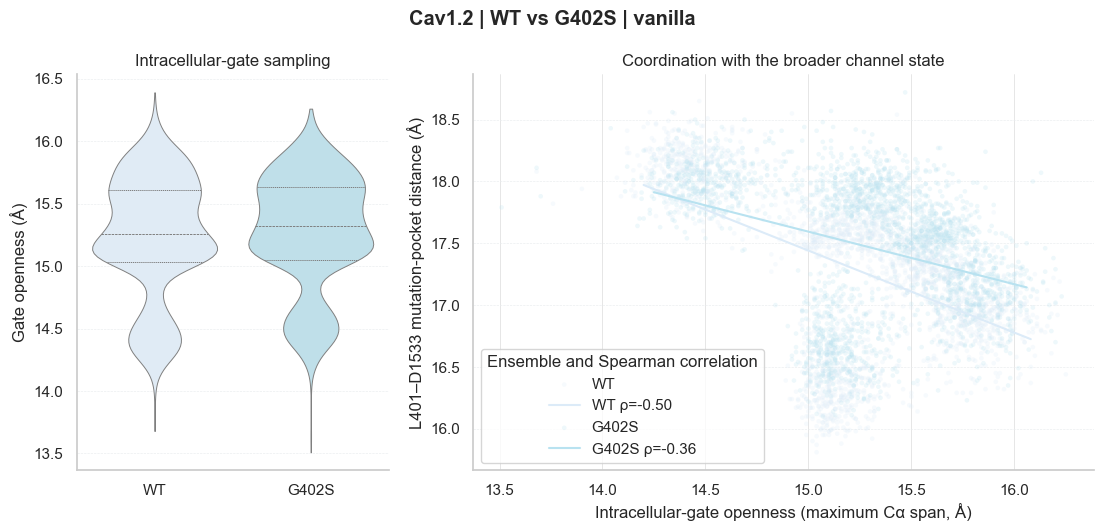

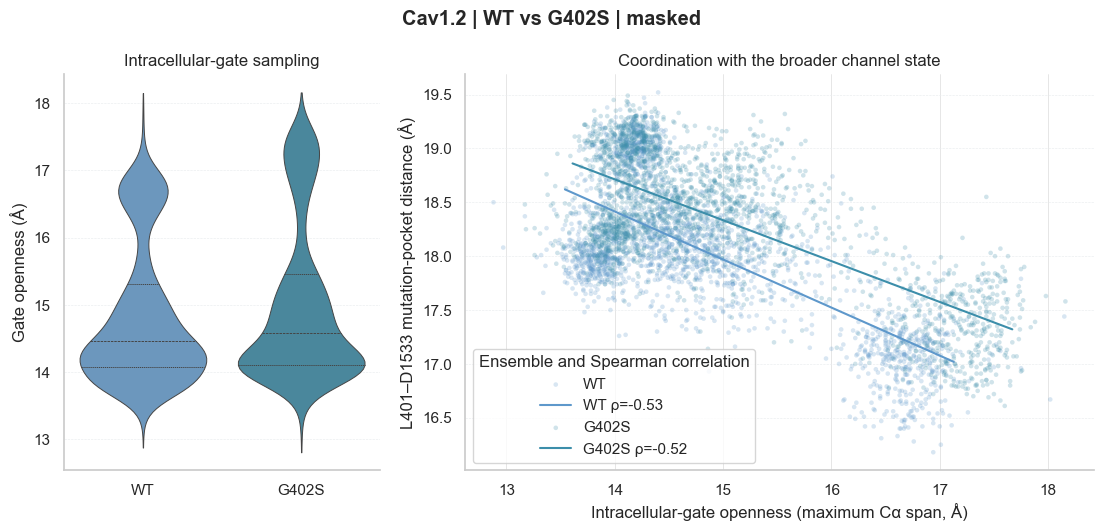

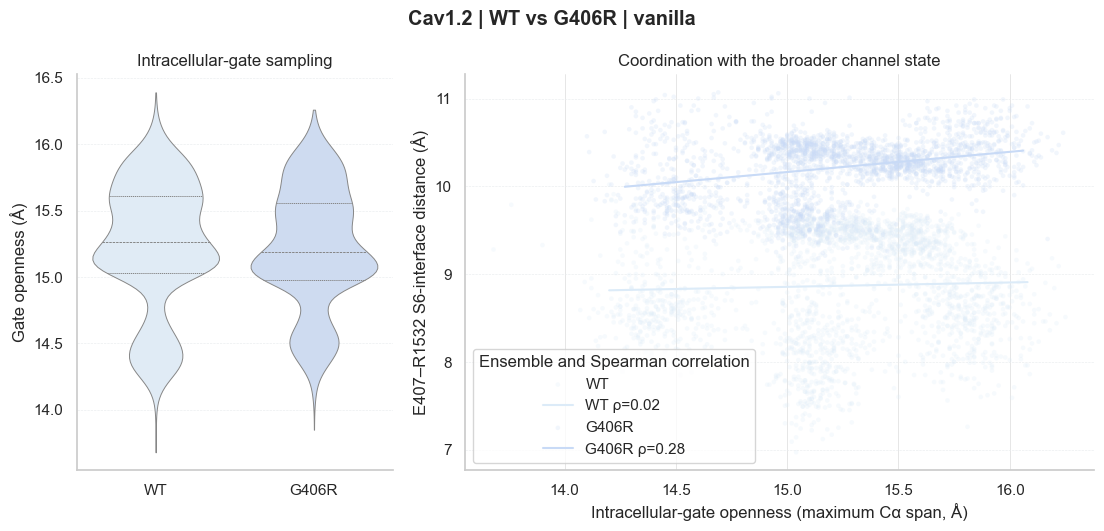

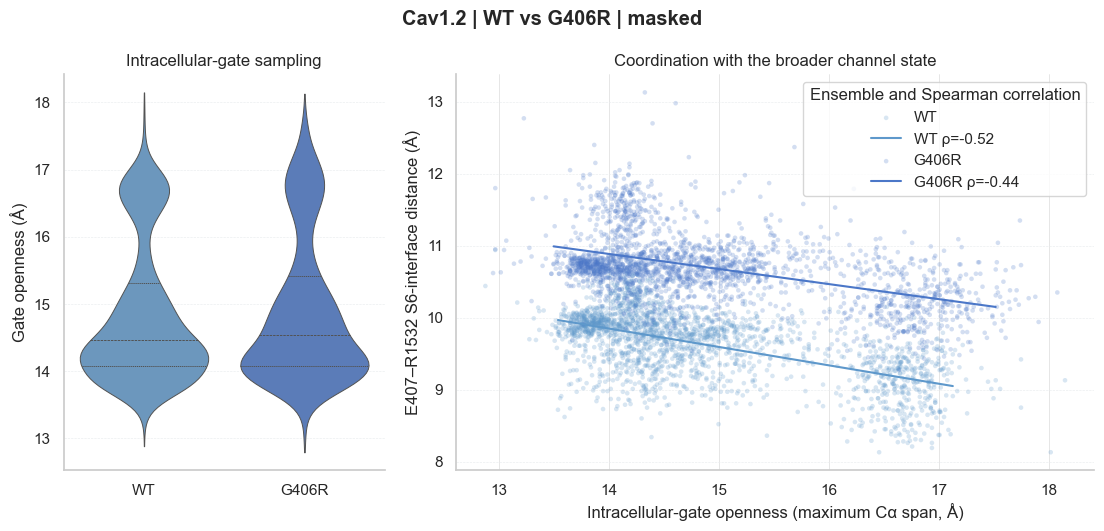

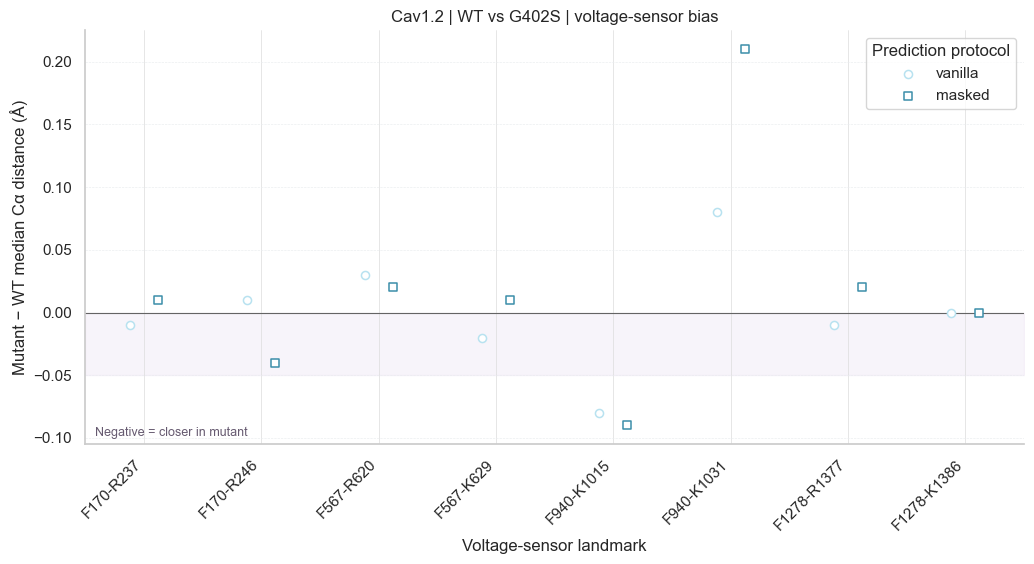

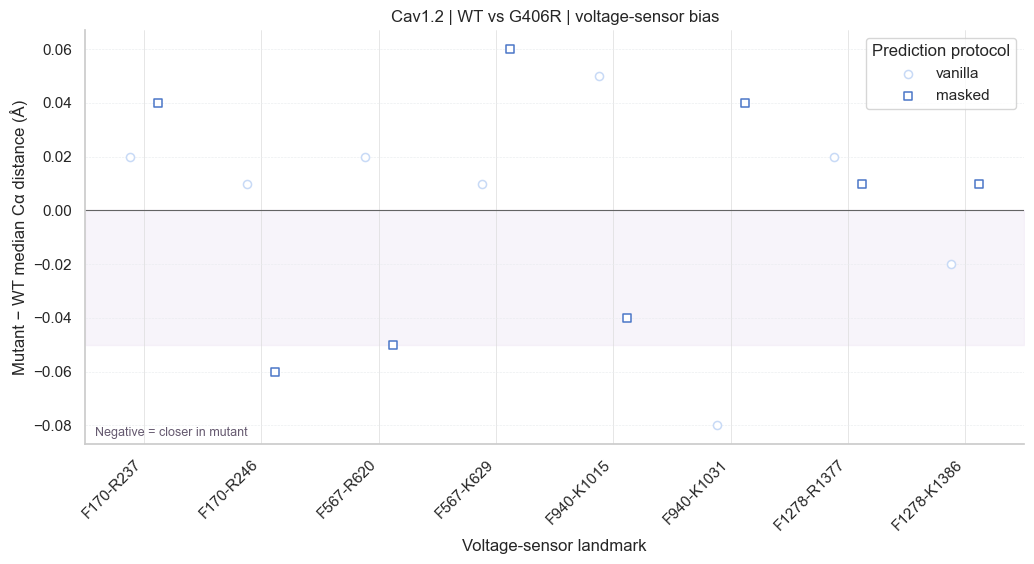

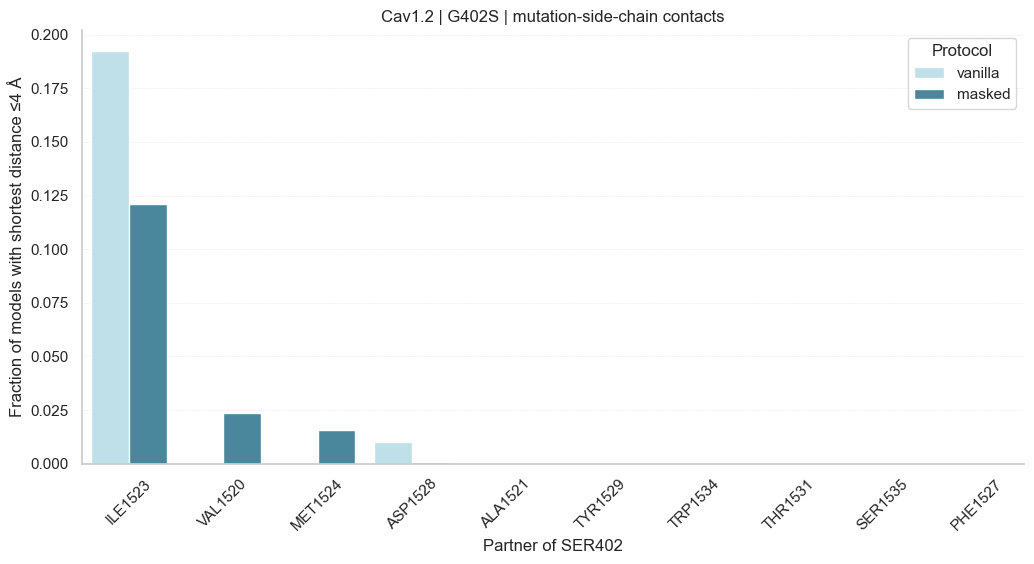

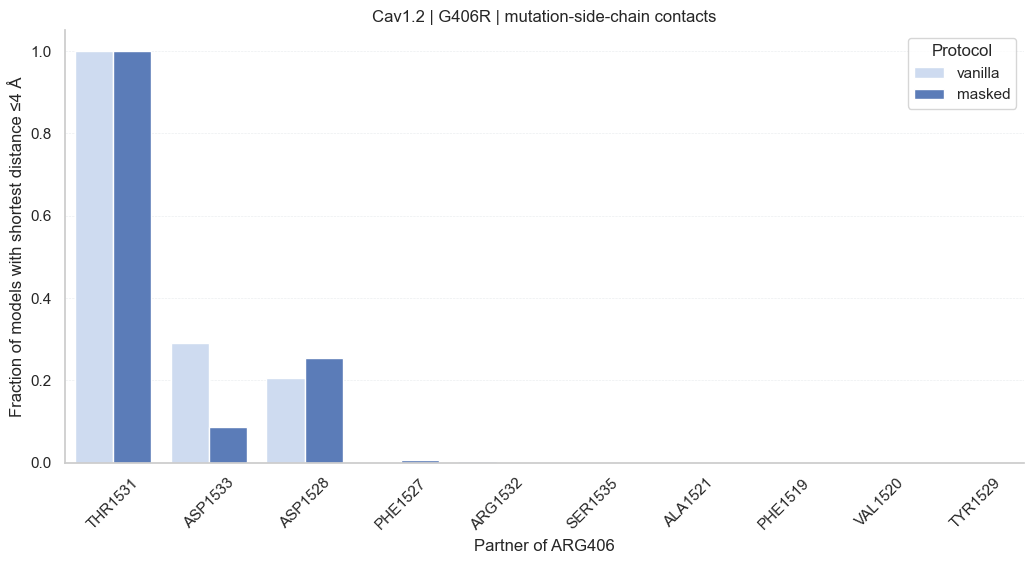

In [15]:
## Split-violin alternatives
import seaborn as sns, matplotlib.pyplot as plt

def cav_split(df1,df2,aliases,label1,label2,title,colors):
 rows=[]
 for a,col in aliases.items():
  for v in pd.to_numeric(df1[col],errors="coerce").dropna(): rows.append({"Alias":a,"Distance":v,"Dataset":label1})
  for v in pd.to_numeric(df2[col],errors="coerce").dropna(): rows.append({"Alias":a,"Distance":v,"Dataset":label2})
 fig,ax=plt.subplots(figsize=(10.5,8)); sns.violinplot(data=pd.DataFrame(rows),x="Alias",y="Distance",hue="Dataset",split=True,inner="quartile",cut=0,palette={label1:colors[0],label2:colors[1]},ax=ax)
 ax.set_title(title); ax.set_xlabel("Residue-pair alias"); ax.set_ylabel("Cα distance (Å)"); ax.tick_params(axis="x",rotation=55); ax.legend(title="Ensemble",bbox_to_anchor=(1.02,1),loc="upper left"); fig.tight_layout(); plt.show()

# The experimental-overlay panels above are used for interpretation.

## Gate openness and coordinated channel-state sampling
# A wider gate distribution is only interpreted as broader state sampling when it
# varies coherently with a second, mutation-relevant coordinate.
from shared.channel_state_analysis import plot_gate_state_comparison
CAV12_GATE_ALIASES = CAV12_MUTATION_CORRESPONDENCE['intracellular_gate']
cav_state_tests = [
    ('G402S', 'vanilla', df_wt_vanilla, df_g402s_vanilla, ['CA_LEU401_CA-ASP1533_CA'], 'L401–D1533 mutation-pocket distance (Å)', [CAV12_PALETTE['WT_VAN'], CAV12_PALETTE['G402S_VAN']]),
    ('G402S', 'masked', df_wt_masked, df_g402s_masked, ['CA_LEU401_CA-ASP1533_CA'], 'L401–D1533 mutation-pocket distance (Å)', [CAV12_PALETTE['WT_HM'], CAV12_PALETTE['G402S_HM']]),
    ('G406R', 'vanilla', df_wt_vanilla, df_g406r_vanilla, ['CA_GLU407_CA-ARG1532_CA'], 'E407–R1532 S6-interface distance (Å)', [CAV12_PALETTE['WT_VAN'], CAV12_PALETTE['G406R_VAN']]),
    ('G406R', 'masked', df_wt_masked, df_g406r_masked, ['CA_GLU407_CA-ARG1532_CA'], 'E407–R1532 S6-interface distance (Å)', [CAV12_PALETTE['WT_HM'], CAV12_PALETTE['G406R_HM']]),
]
cav_gate_state_summary = []
for mutant, protocol, wt_frame, mutant_frame, state_columns, state_label, colors in cav_state_tests:
    summary, _ = plot_gate_state_comparison(wt_frame, mutant_frame, CAV12_GATE_ALIASES, state_columns, state_columns, 'Cav1.2', mutant, protocol, state_label, colors)
    cav_gate_state_summary.append(summary)
cav_gate_state_summary = pd.concat(cav_gate_state_summary, ignore_index=True)
display(cav_gate_state_summary.round(3))

## WT-versus-mutant voltage-sensor bias in both protocols
from shared.channel_state_analysis import plot_vsd_bias
CAV12_VSD_ALIASES = CAV12_MUTATION_CORRESPONDENCE['voltage_sensor']
for mutant, vanilla_frame, masked_frame, colors in [
    ('G402S', df_g402s_vanilla, df_g402s_masked, {'vanilla': CAV12_PALETTE['G402S_VAN'], 'masked': CAV12_PALETTE['G402S_HM']}),
    ('G406R', df_g406r_vanilla, df_g406r_masked, {'vanilla': CAV12_PALETTE['G406R_VAN'], 'masked': CAV12_PALETTE['G406R_HM']}),
]:
    bias_table, _ = plot_vsd_bias(
        {'vanilla': (df_wt_vanilla, vanilla_frame), 'masked': (df_wt_masked, masked_frame)},
        CAV12_VSD_ALIASES, 'Cav1.2', mutant, colors,
    )
    display(bias_table.round(3))
